# TP3 Fonctions descriptives 

Membres de l'équipe : 
- Titouan CHOALER chot4078
- Ethan BROUILLET broe5997

## 1. Segmentation des données suivant la longueur des séquences

### (a). Visualisation de la distribution des longueurs des séquences dans l’ensemble des données à l’aide d’un histogramme

On charge les données, calcule la longueur de chaque séquence d'ARN et génère l'histogramme requis :

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des données
df = pd.read_csv('TP3-data.csv')

# On regarde la description des données, et les premières lignes
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        900 non-null    object
 1   sequence  900 non-null    object
dtypes: object(2)
memory usage: 14.2+ KB


,id,sequence
0,AAIY01303410.1/717-923,CCAACGUGGAUACUCCCGGGAGGUCACUCUCCCCGGGCUCUGUCCA...
1,CP000140.1/4143906-4143709,UACCUUUGCAUCCGAAUUGGUUCCGUACGCUCGUUCGGGCAUACGG...
2,URS0000D6BCE7_12908/1-215,GCGUAACGCGCUAUGGCUUAAACGGCUGCCCCAAAGCUGCCAAAGG...
3,X71081.1/4425-4646,CCAAUGUGGAUAUCCUUAGAGGUCUCUCUUGGGCUCUGUCCAGGUG...
4,AACY020770731.1/455-512,UUUCGUUCACCCUCAAUUGAGGGCGCAGUUCGAGUCAUACCAUGGA...


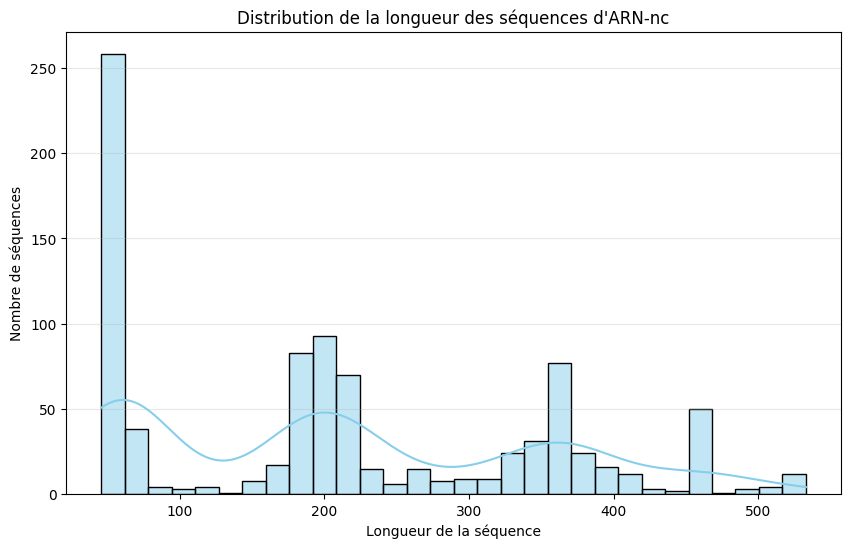

In [2]:
# Calcul de la longueur des séquences
df['longueur'] = df['sequence'].apply(len)

# Visualisation par histogramme 
plt.figure(figsize=(10, 6))
sns.histplot(df['longueur'], bins=30, kde=True, color='skyblue')
plt.title('Distribution de la longueur des séquences d\'ARN-nc')
plt.xlabel('Longueur de la séquence')
plt.ylabel('Nombre de séquences')
plt.grid(axis='y', alpha=0.3)
plt.show()

### (b) Proposition et justification d'un premier partitionnement des données en groupes de séquences de longueurs similaires

Pour aider, à la proposition, on affiche les statistiques lié à la longueur de la séquence.

In [3]:
print(df['longueur'].describe())

count    900.000000
mean     212.873333
std      137.177984
min       46.000000
25%       62.000000
50%      198.000000
75%      345.250000
max      533.000000
Name: longueur, dtype: float64


#### Visualisation et proposition

L'histogramme généré révèle quatre pics distincts dans la distribution des longueurs des 900 séquences d'ARN-nc : 
* Un premier groupe, avec des séquences très courtes, aux environs d'une longueur de $60$. (contient le 1er quartile $62$)
* Un deuxième groupe, avec des séquences d'une longueur intermédiaire, aux environs d'une longueur de $200$. (contient la médiane $198$)
* Un troisième groupe, avec des séquences longues et très longues, aux environs d'une longeur de $360$ et plus. (contient le 3ème quartile $345.25$)

Ainsi, on propose de segmenter les données en quatre groupes distincts :
* Groupe 1 - "Séquences courtes" : $longueur \le 130$
* Groupe 2 - "Séquences moyennes" : $130 < longueur \le 280$
* Groupe 3 - "Séquences longues" : $280 < longueur$

%TODO: VOIR SI ON SUPPRIME
#### Visualisation et proposition (version 4 groupes) 

L'histogramme généré révèle quatre pics distincts dans la distribution des longueurs des 900 séquences d'ARN-nc : 
* Un premier groupe, avec des séquences très courtes, aux environs d'une longueur de $60$. (contient le 1er quartile $62$)
* Un deuxième groupe, avec des séquences d'une longueur intermédiaire, aux environs d'une longueur de $200$. (contient la médiane $198$)
* Un troisième groupe, avec des séquences longues, aux environs d'une longeur de $360$. (contient le 3ème quartile $345.25$)
* Un quatrième groupe, avec des séquences très longues, aux environs d'une longueur de $460$.

Ainsi, on propose de segmenter les données en quatre groupes distincts :
* Groupe 1 - "Séquences courtes" : $longueur \le 130$
* Groupe 2 - "Séquences moyennes" : $130 < longueur \le 280$
* Groupe 3 - "Séquences longues" : $280 < longueur \le 420$
* Groupe 4 - "Séquences très longues" : $420 < longueur$

#### Justification



Le choix de cette segmentation a plusieurs raisons : 
* L'histogramme montre clairement 3 à 4 familles de longueurs différentes. En en effet, on remarque 3 groupes, tel que proposé juste au-dessus. Le choix des trois premier groupes est évident, on remarque vraiment un amas de séquences autour des longueurs de séquences 60, 200, et 360. Le choix d'un quatrième groupe aurait pu être une possibilité car on remarque un amas/un pic certes plus petit, autour de la longueur de séquence 460. Ce choix de ce 4ème groupe aurait permet d'isoler les séquences de plus 450 nucléotiqudes qui ont probablement des propriétés structurales très différences de celles de 350 nucléotides ! Cependant, ce 4ième groupe aurait eu une taille très petite par rapport aux 3 autres groupes, et afin d'avoir 3 groupes de taille similaire, on a préféré rester sur l'idée de 3 groupes.
* Les seuils qu'on a choisis, $125$ et $280$ tombent vers les creux entre les pics, où la densité de séquences est la plus faible ( pour cela on doit faire attention à la courbe sur l'histogramme). Ce choix là, permet de minimiser le risque de séparer une même famille biologique de ARN en deux !
* Chaque bond de 25% (1er quartile, médiane, 3ème quartile) sur notre diagramme correspond à un pics ! Ce qui permet de nous assurer que les 3 groupes auront une taille d'échantillon suffisante pour les algorithmes des questions suivantes.      

%TODO : Est-ce qu'on garde le groupe 4 ? 

#### Implémentation de la segmentation :

In [4]:
# Seuils pour 4 groupes
seuils = [130, 280]

# Création des listes de groupes
g_court = df[df['longueur'] < seuils[0]].copy()
g_moyen = df[(df['longueur'] >= seuils[0]) & (df['longueur'] < seuils[1])].copy()
g_long = df[(df['longueur'] >= seuils[1])].copy()

# Affichage pour validation
groupes = [g_court, g_moyen, g_long]
for i, g in enumerate(groupes, 1):
    print(f"Groupe {i} : {len(g)} séquences (Min: {g['longueur'].min()}, Max: {g['longueur'].max()})")

Groupe 1 : 307 séquences (Min: 46, Max: 127)
Groupe 2 : 311 séquences (Min: 136, Max: 277)
Groupe 3 : 282 séquences (Min: 280, Max: 533)


## 2. Partitionnement à partir d’une représentation vectorielle des données

### (a). Génération d'une représentation vectorielle des séquences (2-mer, 3-mer et 4-mer)

Dans cette étape, nous allons transformer chaque séquence (chaîne de caractères composée de A, C, G, U ) en un vecteur de fréquences. Un $k$-mer est simplement une sous-chaîne de longueur $k$.
* 2-mers : AA, AC, AG, AU, CA, etc. ($4^2 = 16$ combinaisons).
* 3-mers : AAA, AAC, etc. ($4^3 = 64$ combinaisons).
* 4-mers : AAAA, AAAC, etc. ($4^4 = 256$ combinaisons).   

Total des attributs par vecteur : $16 + 64 + 256 = 336$.   

Voici le code pour générer ces matrices pour chacun de vos trois groupes :

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
import itertools
import pandas as pd

def extraire_kmers(df_groupe):
    """
    Génère une représentation vectorielle basée sur les 2-mer, 3-mer et 4-mer.
    """
    alphabet = ['A', 'C', 'G', 'U']
    
    # Génération de la liste complète de tous les k-mers possibles (le vocabulaire)
    vocabulaire_complet = []
    for k in [2, 3, 4]:
        combinaisons = [''.join(p) for p in itertools.product(alphabet, repeat=k)]
        vocabulaire_complet.extend(combinaisons)
    
    # Initialisation du CountVectorizer
    # analyzer='char' permet de regarder les suites de caractères
    # ngram_range=(2, 4) extrait les séquences de 2, 3 et 4 lettres
    vectorizer = CountVectorizer(analyzer='char', 
                                 ngram_range=(2, 4),
                                 lowercase=False, # Ne pas convertir en minuscules  
                                 vocabulary=vocabulaire_complet)
    
    # Transformation des séquences en matrice de fréquences (comptes)
    X = vectorizer.fit_transform(df_groupe['sequence'])
    
    # Conversion en DataFrame pour faciliter les manipulations suivantes
    df_vectorise = pd.DataFrame(X.toarray(), 
                                columns=vectorizer.get_feature_names_out(), 
                                index=df_groupe.index)
    
    return df_vectorise

# Application de la fonction à vos 3 groupes définis à la Partie 1
X_court = extraire_kmers(g_court)
X_moyen = extraire_kmers(g_moyen)
X_long = extraire_kmers(g_long)

print(f"Dimensions de la matrice 'Court' : {X_court.shape}") # Devrait être (nb_sequences, 336)

Dimensions de la matrice 'Court' : (307, 336)


Comme les algorithmes de partitionnement (K-means) ne peuvent pas traiter directement du texte, cette méthode de "sac de mots" (bag-of-words) adaptée à la biologie permet de projeter les propriétés structurelles des ARN dans un espace numérique. Chaque colonne représente maintenant la fréquence d'apparition d'un motif spécifique.

### (b). Filtrage des motifs fréquents

Un motif (sous-chaîne) est considéré comme frequent si sa proportion de présence dans l'ensemble des séquences d'un groupe est supérieure ou égale à $1/3$. Pour chaque groupe, nous devons supprimer les attributs (colonnes) correspondant aux motifs non-fréquents.   

Voici le code pour effectuer ce filtrage sur vos trois matrices :

In [13]:
def filtrer_motifs_frequents(df_vectorise):
    """
    Supprime les colonnes (motifs) dont la proportion de présence est < 1/3.
    """
    # On transforme les comptes en présence binaire (1 si présent, 0 sinon)
    presence = (df_vectorise > 0).astype(int)
    
    # Calcul de la proportion de séquences contenant chaque motif
    proportion = presence.mean()
    
    # Conservation uniquement des motifs avec une proportion >= 1/3
    motifs_a_garder = proportion[proportion >= 1/3].index
    
    return df_vectorise[motifs_a_garder]

# Application du filtre à chaque groupe
X_court_filtre = filtrer_motifs_frequents(X_court)
X_moyen_filtre = filtrer_motifs_frequents(X_moyen)
X_long_filtre = filtrer_motifs_frequents(X_long)

print(f"Colonnes restantes (Court) : {X_court_filtre.shape[1]}")
print(f"Colonnes restantes (Moyen) : {X_moyen_filtre.shape[1]}")
print(f"Colonnes restantes (Long)  : {X_long_filtre.shape[1]}")

Colonnes restantes (Court) : 108
Colonnes restantes (Moyen) : 322
Colonnes restantes (Long)  : 335


Pourquoi est-il important de retirer les motifs les moins fréquents ?    

Il est crucial de nettoyer la représentation vectorielle pour plusieurs raisons :
* Réduction de la dimensionnalité : Avec les 2, 3 et 4-mers, nous commençons avec 336 attributs. Beaucoup de ces motifs sont rares ou uniques à une seule séquence. Réduire ce nombre limite le risque de "fléau de la dimension" (curse of dimensionality), où les distances entre les points deviennent moins significatives.
* Élimination du bruit : Les motifs très peu fréquents peuvent être des bruits de séquençage ou des motifs non fonctionnels. En les supprimant, on se concentre sur les caractéristiques partagées qui définissent réellement une famille d'ARN.
* Efficacité algorithmique : Moins d'attributs signifient des calculs beaucoup plus rapides pour l'algorithme des $k$-moyennes et le calcul du coefficient de Silhouette à l'étape suivante.
* Amélioration de la cohésion des clusters : Le partitionnement cherche à regrouper des objets similaires. Les motifs fréquents agissent comme des "signatures" communes qui aident l'algorithme à identifier la structure globale des données plutôt que de se perdre dans des détails isolés.

### (c). Recherche du nombre optimal de clusters ($k$) par K-moyennes

L'objectif ici est de déterminer, pour chacun des trois groupes de longueurs définis à la question 1, le nombre de familles d'ARN ($k$) le plus cohérent. Pour ce faire, nous utilisons l'algorithme des **k-moyennes (k-means)** et évaluons la qualité du partitionnement avec le **coefficient de Silhouette**.   
Le coefficient de Silhouette varie entre -1 et 1 : 
* Proche de 1 : Les données sont très bien classées dans leur cluster et loin des autres.
* Proche de 0 : Les clusters se chevauchent.
* Négatif : Des données ont probablement été assignées au mauvais cluster.

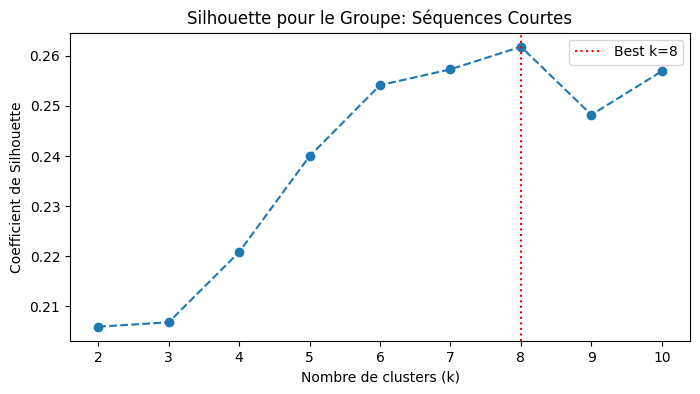

Pour le groupe Séquences Courtes, la meilleure valeur est k = 8 (Score: 0.2618)


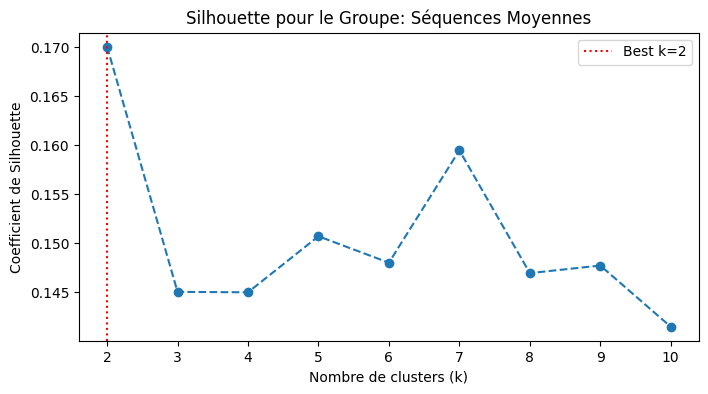

Pour le groupe Séquences Moyennes, la meilleure valeur est k = 2 (Score: 0.1700)


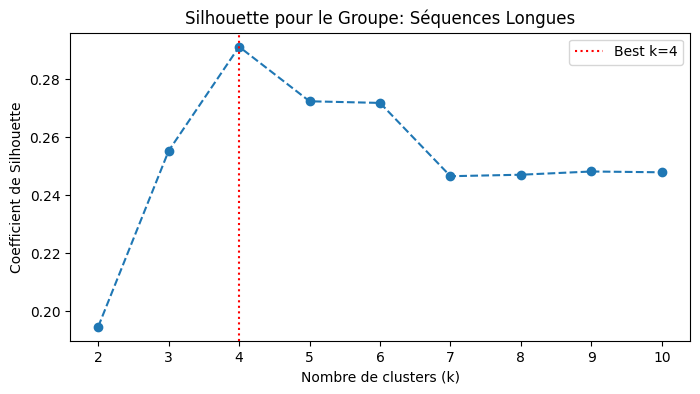

Pour le groupe Séquences Longues, la meilleure valeur est k = 4 (Score: 0.2912)


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

def trouver_meilleur_k(X, nom_groupe, k_min=2, k_max=10):
    """
    Teste plusieurs valeurs de k pour un groupe donné et retourne le meilleur k
    selon le score de Silhouette.
    """
    scores = []
    meilleur_k = k_min
    meilleur_score = -1
    
    plage_k = range(k_min, k_max + 1)
    
    for k in plage_k:
        # Initialisation de K-means
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = kmeans.fit_predict(X)
        
        # Calcul du score de Silhouette
        score = silhouette_score(X, labels)
        scores.append(score)
        
        if score > meilleur_score:
            meilleur_score = score
            meilleur_k = k
            
    # Visualisation des résultats
    plt.figure(figsize=(8, 4))
    plt.plot(plage_k, scores, marker='o', linestyle='--')
    plt.title(f'Silhouette pour le Groupe: {nom_groupe}')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Coefficient de Silhouette')
    plt.axvline(x=meilleur_k, color='r', linestyle=':', label=f'Best k={meilleur_k}')
    plt.legend()
    plt.show()
    
    print(f"Pour le groupe {nom_groupe}, la meilleure valeur est k = {meilleur_k} (Score: {meilleur_score:.4f})")
    return meilleur_k

# Exécution pour chaque groupe de la question 1 [cite: 20, 21]
k_court = trouver_meilleur_k(X_court_filtre, "Séquences Courtes")
k_moyen = trouver_meilleur_k(X_moyen_filtre, "Séquences Moyennes")
k_long  = trouver_meilleur_k(X_long_filtre,  "Séquences Longues")

## 3. Partitionnement à partir d'une matrice de distances

### (a). Génération de la matrice des distances d'édition

Le calcul d'une matrice de distances est coûteux en temps (complexité en $O(n^2)$). Comme la distance entre $S_1$ et $S_2$ est la même que celle entre $S_2$ et $S_1$, nous allons optimiser le code pour ne calculer que la moitié de la matrice.  

Voici le script pour générer les matrices de distances pour vos groupes :

In [17]:
from Bio import pairwise2
import numpy as np

def calculer_matrice_distances(df_groupe):
    """
    Calcule la matrice carrée des distances d'édition simple entre les séquences.
    """
    n = len(df_groupe)
    sequences = df_groupe['sequence'].tolist()
    # Initialisation d'une matrice de zéros
    matrice_dist = np.zeros((n, n))
    
    print(f"Calcul de la matrice pour {n} séquences...")
    
    for i in range(n):
        for j in range(i + 1, n):
            # Calcul de l'alignement global
            # globalxx: match=1, mismatch=0, gap_open=0, gap_extend=0
            alignments = pairwise2.align.globalxx(sequences[i], sequences[j])
            
            # Formule fournie dans l'énoncé : distance = min(longueur - score)
            # alignment[i][4] est la fin de l'alignement (longueur)
            # alignment[i][2] est le score
            dist = min([aln[4] - aln[2] for aln in alignments])
            
            # La matrice est symétrique
            matrice_dist[i, j] = dist
            matrice_dist[j, i] = dist
            
        if (i + 1) % 50 == 0:
            print(f"Progression : {i + 1}/{n} séquences traitées")
            
    return matrice_dist

# Calcul des matrices pour chaque groupe (Utilisez les groupes de la Q1)
# Note : Cela peut prendre plusieurs minutes selon la puissance de votre machine
dist_court = calculer_matrice_distances(g_court)
dist_moyen = calculer_matrice_distances(g_moyen)
dist_long  = calculer_matrice_distances(g_long)

print("Matrices de distances générées avec succès.")

/home/titouan/miniconda3/envs/udes_sd_a25/lib/python3.12/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Calcul de la matrice pour 307 séquences...
Progression : 50/307 séquences traitées
Progression : 100/307 séquences traitées
Progression : 150/307 séquences traitées
Progression : 200/307 séquences traitées
Progression : 250/307 séquences traitées
Progression : 300/307 séquences traitées
Calcul de la matrice pour 311 séquences...
Progression : 50/311 séquences traitées
Progression : 100/311 séquences traitées
Progression : 150/311 séquences traitées
Progression : 200/311 séquences traitées
Progression : 250/311 séquences traitées
Progression : 300/311 séquences traitées
Calcul de la matrice pour 282 séquences...
Progression : 50/282 séquences traitées
Progression : 100/282 séquences traitées
Progression : 150/282 séquences traitées
Progression : 200/282 séquences traitées
Progression : 250/282 séquences traitées
Matrices de distances générées avec succès.


### (b). Implémentation de la fonction KMedoid

Cette fonction utilise exclusivement la matrice de distances $X$ fournie en paramètre.

In [18]:
import numpy as np

def KMedoid(n_clusters, X, max_iter=100):
    """
    Implémentation de l'algorithme k-médoïdes.
    
    Paramètres:
    - n_clusters : Nombre de clusters souhaités 
    - X : Matrice carrée (n x n) de distances 
    
    Retourne:
    - y : Vecteur de dimension n contenant les indices de cluster [0, n_clusters-1] 
    """
    n = X.shape[0]
    
    # 1. Initialisation : Choix aléatoire de n_clusters indices comme médoïdes initiaux
    indices_medoides = np.random.choice(n, n_clusters, replace=False)
    
    # Initialisation du vecteur d'étiquettes
    y = np.zeros(n, dtype=int)
    
    for _ in range(max_iter):
        # --- ÉTAPE D'AFFECTATION ---
        # Pour chaque point, on trouve le médoïde le plus proche en utilisant la matrice X
        distances_aux_medoides = X[:, indices_medoides]
        y_nouveau = np.argmin(distances_aux_medoides, axis=1)
        
        # Vérification de la convergence (si les assignations ne changent plus)
        if np.array_equal(y, y_nouveau):
            break
        y = y_nouveau
        
        # --- ÉTAPE DE MISE À JOUR ---
        nouveaux_indices_medoides = np.zeros(n_clusters, dtype=int)
        
        for k in range(n_clusters):
            # Extraction des indices des points appartenant au cluster k
            indices_cluster_k = np.where(y == k)[0]
            
            if len(indices_cluster_k) == 0:
                # Si un cluster est vide, on garde l'ancien médoïde ou on en pioche un au hasard
                nouveaux_indices_medoides[k] = indices_medoides[k]
                continue
                
            # On cherche le point dans le cluster k qui minimise la somme des distances 
            # vers les autres points du même cluster 
            sous_matrice_dist = X[np.ix_(indices_cluster_k, indices_cluster_k)]
            somme_distances = sous_matrice_dist.sum(axis=1)
            
            # L'indice du nouveau médoïde local au cluster
            index_local_medoide = np.argmin(somme_distances)
            nouveaux_indices_medoides[k] = indices_cluster_k[index_local_medoide]
            
        indices_medoides = nouveaux_indices_medoides
            
    return y

### (c). Recherche de la meilleure valeur de $k$ pour les k-médoïdes

In [19]:
from sklearn.metrics import silhouette_score

def trouver_meilleur_k_medoide(matrice_dist, nom_groupe, k_min=2, k_max=10):
    scores = []
    meilleur_k = k_min
    meilleur_score = -1
    
    for k in range(k_min, k_max + 1):
        # Appel de votre fonction KMedoid 
        labels = KMedoid(k, matrice_dist)
        
        # Calcul du coefficient de Silhouette 
        # Attention : spécifier metric="precomputed" car on passe une matrice de distances
        score = silhouette_score(matrice_dist, labels, metric="precomputed")
        scores.append(score)
        
        if score > meilleur_score:
            meilleur_score = score
            meilleur_k = k
            
    print(f"Meilleur k pour {nom_groupe} (K-Médoïdes) : {meilleur_k} (Score: {meilleur_score:.4f})")
    return meilleur_k

# Exécution pour les trois groupes
k_med_court = trouver_meilleur_k_medoide(dist_court, "Séquences Courtes")
k_med_moyen = trouver_meilleur_k_medoide(dist_moyen, "Séquences Moyennes")
k_med_long  = trouver_meilleur_k_medoide(dist_long,  "Séquences Longues")

Meilleur k pour Séquences Courtes (K-Médoïdes) : 6 (Score: 0.3584)
Meilleur k pour Séquences Moyennes (K-Médoïdes) : 9 (Score: 0.1942)
Meilleur k pour Séquences Longues (K-Médoïdes) : 9 (Score: 0.2888)


## 4. Analyse de la signification sémantique

### (a). Analyse par représentation vectorielle (K-moyennes)

Pour cette analyse, on doit dentifier quels motifs (k-mers) définissent nos clusters. Puisque les ARN d'un même groupe fonctionnel partagent souvent des sous-chaînes communes importantes pour leur fonction, nous allons chercher les motifs "signatures".   
On va procéder en 3 étapes.    
Premièrement, on va prendre nos clusters obtenues par K-moyennes, puis deuxièment, pour chque cluster on va calculer la fréquence moyenne de chaque k-mer. En fin, on va identier les k-mers qui ont une fréquence élevée dans un cluster, mais faible dans les autres.

Nous utilisons les meilleurs $k$ identifiés précédemment ($k=8, 2, 4$ à la question 2.(c)) pour extraire les caractéristiques communes et spécifiques.

In [22]:
from sklearn.cluster import KMeans

# 1. Génération des labels avec les meilleurs k trouvés à la question 2(c)
# k_court=8, k_moyen=2, k_long=4
model_court = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X_court_filtre)
labels_court_km = model_court.labels_

model_moyen = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X_moyen_filtre)
labels_moyen_km = model_moyen.labels_

model_long = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_long_filtre)
labels_long_km = model_long.labels_

def analyser_clusters_kmers(X_filtre, labels, nom_groupe):
    print(f"=== ANALYSE : {nom_groupe} (K-moyennes) ===")
    df_temp = X_filtre.copy()
    df_temp['cluster'] = labels
    
    moyenne_globale = X_filtre.mean()
    moyennes_clusters = df_temp.groupby('cluster').mean()
    
    # Caractéristiques communes (Top 5 motifs les plus présents dans tout le groupe)
    communs = moyenne_globale.sort_values(ascending=False).head(5).index.tolist()
    print(f"Motifs communs au groupe : {communs}")
    
    # Caractéristiques spécifiques (Top 3 par cluster vs moyenne globale)
    for i in range(len(moyennes_clusters)):
        specif = (moyennes_clusters.loc[i] - moyenne_globale).sort_values(ascending=False).head(3).index.tolist()
        print(f"  > Cluster {i} - Signatures spécifiques : {specif}")
    print("-" * 50)

# Exécution de l'analyse
analyser_clusters_kmers(X_court_filtre, labels_court_km, "Séquences Courtes")
analyser_clusters_kmers(X_moyen_filtre, labels_moyen_km, "Séquences Moyennes")
analyser_clusters_kmers(X_long_filtre, labels_long_km, "Séquences Longues")

=== ANALYSE : Séquences Courtes (K-moyennes) ===
Motifs communs au groupe : ['AA', 'GC', 'CA', 'AU', 'UG']
  > Cluster 0 - Signatures spécifiques : ['AA', 'AAA', 'UUG']
  > Cluster 1 - Signatures spécifiques : ['GC', 'CC', 'AG']
  > Cluster 2 - Signatures spécifiques : ['UA', 'AU', 'CAA']
  > Cluster 3 - Signatures spécifiques : ['AA', 'UA', 'UAA']
  > Cluster 4 - Signatures spécifiques : ['CC', 'CG', 'GG']
  > Cluster 5 - Signatures spécifiques : ['CC', 'GC', 'GG']
  > Cluster 6 - Signatures spécifiques : ['GG', 'GGG', 'UC']
  > Cluster 7 - Signatures spécifiques : ['GU', 'AG', 'AGU']
--------------------------------------------------
=== ANALYSE : Séquences Moyennes (K-moyennes) ===
Motifs communs au groupe : ['AA', 'UG', 'GG', 'AG', 'GA']
  > Cluster 0 - Signatures spécifiques : ['CC', 'CG', 'GG']
  > Cluster 1 - Signatures spécifiques : ['AA', 'UA', 'UU']
--------------------------------------------------
=== ANALYSE : Séquences Longues (K-moyennes) ===
Motifs communs au groupe : [

### (b). Analyse par matrice de distances (K-médoïdes)

Nous identifions ici la séquence réelle (médoïde) représentative de chaque cluster. Nous utilisons tes meilleurs $k$ ($k=6, 9, 9$). obtenus à la question 3.(c).

In [23]:
# 1. Génération des labels avec les meilleurs k trouvés à la question 3(c)
# Note : On utilise la fonction KMedoid définie en 3(b)
labels_court_med = KMedoid(6, dist_court)
labels_moyen_med = KMedoid(9, dist_moyen)
labels_long_med  = KMedoid(9, dist_long)

def extraire_representants(df_original, matrice_dist, labels, nom_groupe):
    print(f"=== REPRÉSENTANTS : {nom_groupe} (K-médoïdes) ===")
    clusters_uniques = np.unique(labels)
    
    for k in clusters_uniques:
        indices_cluster = np.where(labels == k)[0]
        
        # Identification du médoïde dans la matrice de distances
        sous_matrice = matrice_dist[np.ix_(indices_cluster, indices_cluster)]
        idx_medoide_local = np.argmin(sous_matrice.sum(axis=1))
        idx_reel = indices_cluster[idx_medoide_local]
        
        row = df_original.iloc[idx_reel]
        print(f"Cluster {k} | ID: {row['id']} | Séquence (début): {row['sequence'][:50]}...")
    print("-" * 50)

# Exécution de l'analyse
extraire_representants(g_court, dist_court, labels_court_med, "Séquences Courtes")
extraire_representants(g_moyen, dist_moyen, labels_moyen_med, "Séquences Moyennes")
extraire_representants(g_long, dist_long, labels_long_med, "Séquences Longues")

=== REPRÉSENTANTS : Séquences Courtes (K-médoïdes) ===
Cluster 0 | ID: URS0000D6890F_1069617/1-62 | Séquence (début): CAUCUAUAGUUUCAGACAUGGAAUCGCCGAAAACGUCGGCGGUAAAUGCA...
Cluster 1 | ID: AACY020923398.1/499-558 | Séquence (début): UAAACAGAGGAAGGAUUUGACUGAUUGCAACCUCUUAAAAAAAUUGCUAA...
Cluster 2 | ID: URS0000D67FB8_366394/1-61 | Séquence (début): CAUUGGUGCCGGGCCCCUCUGGCGAGAGUUUACGGCGCUCUCGCGAUGUC...
Cluster 3 | ID: AACY021019598.1/799-738 | Séquence (début): CGACGUUCACCUCGCUUCCAGCGAGGCGCAGUUCGACUCAGGCCAUGGAA...
Cluster 4 | ID: AACY021220275.1/163-106 | Séquence (début): UUUCGUUCACCCUCAUUUGAGGGCGCAGUUCGAGUCAUACCAUGGAACGG...
Cluster 5 | ID: AF231763.1/4363-4423 | Séquence (début): GAUGAGCAAUUACAUACAGUUCAAGUCCAAAUGCCGUAUUGAACCUGUAU...
--------------------------------------------------
=== REPRÉSENTANTS : Séquences Moyennes (K-médoïdes) ===
Cluster 0 | ID: AACN010016018.1/3148-3351 | Séquence (début): CCAACGUGGAUACUCCCGGGAGGUCACUCUCCCCGGGCUCUGUCCAGGUG...
Cluster 1 | ID: URS0000D6A292_12908/

### (c). Justification de l'approche

L'approche par représentation vectorielle (Question 2) offre une analyse plus approfondie de la signification sémantique. Pourquoi ? Elle permet de décomposer les séquences en motifs (k-mers) interprétables. En identifiant précisément quels triplets ou quadruplets de nucléotides sont sur-représentés, on peut faire le lien avec des fonctions biologiques connues (comme des sites de fixation de protéines ou des structures de repliement). À l'inverse, l'approche par matrice de distances (Question 3) est une boîte noire : elle confirme que des séquences se ressemblent globalement sans expliquer quels sous-éléments (motifs) créent cette similarité.